# Implied Volatility Using Brent's method

## 1. Brent's method
- We use Brent's root-finding algorithm (implemented in scipy.optimize.brentq) to solve for implied volatility.
- The method finds the root of a nonlinear equation with a specified interval (i.e., the lower and upper bounds).

## 2. Two Examples
We illustrate the implied volatility calculation using two models:
- European Call Option
  - We use the Black-Scholes-Merton (BSM) formula to compute the theoretical price.
- American Put Option
  - We use the binomial tree model to compute the theoretical price.
 
## 3. Important Limitation
- There is a fundamental limitation in implied volatility inversion. When volatility is very small, the theoretical option price becomes nearly insensitive to volatility. 
----
## Import Packages and Functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath("../src"))

from black_scholes_merton import price_option_bsm
from binomial_model import price_option_tree
from implied_vol import implied_vol_brent
from greeks import vega_bsm, vega_tree

## 1. Example-1: European Call

In this example, we examine the consistency between the true volatility and the implied volatility recovered using Brent's method.

- We compute the theoretical option price using the Black-Scholes-Merton (BSM) formula.
  - We then recover the implied volatility from this theoretical price using Brent's method.
- The plot displays Implied Volatility - True Volatility, together with the corresponding BSM Vega.
  - Important observation: The option is deep in-the-money (S=100, K=50). When volatility is very small (e.g., 0.1 or 0.001), the BSM price converges to the discounted intrinsic value, and the theoretical prices become nearly identical.
  - As a result, Vega is close to zero (as shown by the Vega curve). The implied volatility inversion becomes numerically ill-conditioned.
  - This demonstrates a fundamental limitation of implied volatility recovery when the option price is insensitive to volatility.

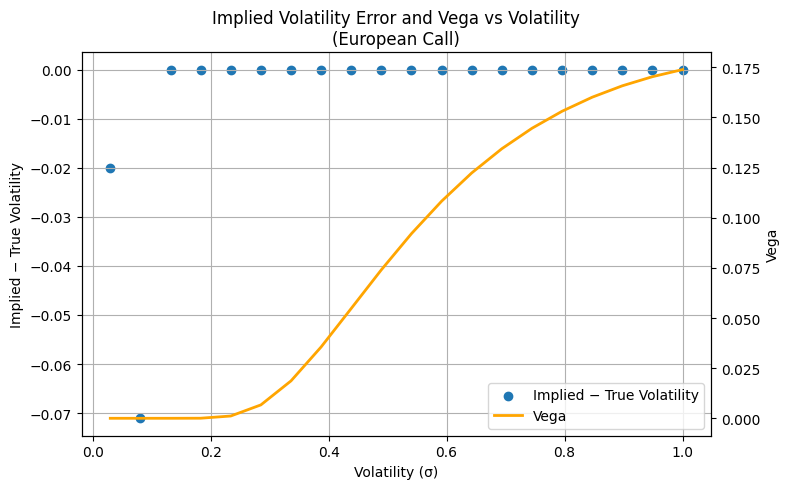

In [2]:
# parameters
s = 100
k = 50
T = 1
r = 0.1
q = 0.02

option_type = 'call'
exercise_style = 'European'

sigma_vals = np.linspace(0.03, 1, 20)
implied_vol_vals = np.zeros_like(sigma_vals)
vega_vals = np.zeros_like(sigma_vals)

# compute implied volatilities

for i, sigma in enumerate(sigma_vals):

    # theoretical BSM price
    price_bsm = price_option_bsm(option_type, exercise_style, s, k, r, sigma, T, q)
    # recover implied volatility
    implied_vol_vals[i] = implied_vol_brent(option_type, exercise_style, price_bsm, s, k, r, T, q, sigma_low=1e-2, sigma_high=1)
    # the vega from BSM
    vega_vals[i] = vega_bsm(s, k, r, sigma, T, q)

vol_error = implied_vol_vals - sigma_vals

fig, ax1 = plt.subplots(figsize=(8,5))

# Left axis: Implied vol error
ax1.scatter(sigma_vals, vol_error, label='Implied − True Volatility')
ax1.set_xlabel('Volatility (σ)')
ax1.set_ylabel('Implied − True Volatility')
ax1.grid(True)

# Right axis: Vega (orange)
ax2 = ax1.twinx()
ax2.plot(sigma_vals, vega_vals, color='orange', linewidth=2, label='Vega')
ax2.set_ylabel('Vega')

# Title
plt.title('Implied Volatility Error and Vega vs Volatility\n(European Call)')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.show()

In [3]:
print(price_option_bsm(option_type, exercise_style, s, k, r, 0.1, T, q))
print(price_option_bsm(option_type, exercise_style, s, k, r, 1e-4, T, q))

52.77799642887755
52.77799642887755


## 2. Example-2: American Put

In this example, we examine the consistency between the true volatility and the implied volatility recovered using Brent's method.

- We compute the theoretical option price using the binomial Tree model, which allows for early exercise.
  - We then recover the implied volatility from this theoretical price using Brent's method.
- The plot displays Implied Volatility - True Volatility, together with the corresponding tree-based Vega.
  - If the inversion is numerically stable, the difference should be close to zero.
  - Important observation: The option is in-the-money (S=45, K=50). When volatility is very small (e.g., 0.1 or 0.001), early exercise becomes almost certain, and the pricing function becomes nearly flat with respect to volatility.
  - As a result, Vega is close to zero (as shown by the Vega curve). The implied volatility inversion becomes numerically ill-conditioned.
  - This demonstrates a fundamental limitation of implied volatility recovery when the option price is insensitive to volatility.

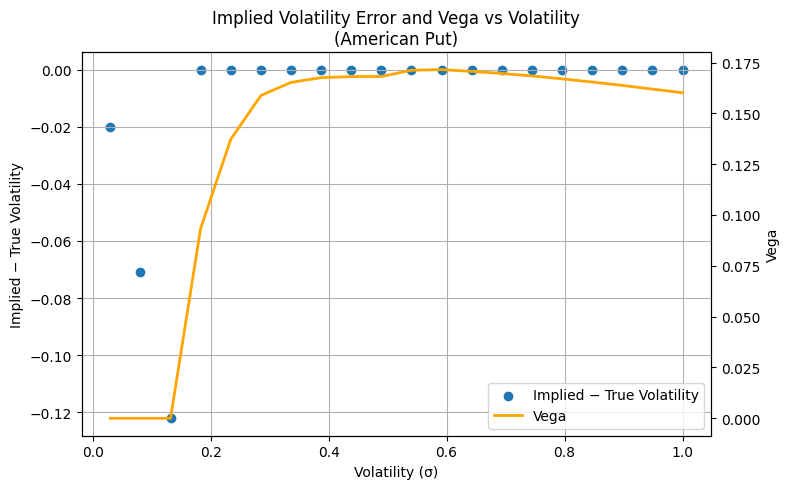

In [4]:
# parameters
s = 45
k = 50
T = 1
r = 0.1
q = 0.02
N=100

option_type = 'put'
exercise_style = 'American'

sigma_vals = np.linspace(0.03, 1, 20)
implied_vol_vals = np.zeros_like(sigma_vals)
vega_vals = np.zeros_like(sigma_vals)

# compute the implied volatilities

for i, sigma in enumerate(sigma_vals):
    # theoretical Tree price
    price_tree = price_option_tree(option_type, exercise_style, s, k, r, sigma, T, N=N, q=q)
    # recover implied volatility
    implied_vol_vals[i] = implied_vol_brent(option_type, exercise_style, price_tree, s, k, r, T, q, sigma_low=1e-2, sigma_high=2, N=N)
    # the vega
    vega_vals[i] = vega_tree(option_type, exercise_style, s, k, sigma, T, N, r, q, epsilon=1e-4)

vol_error = implied_vol_vals - sigma_vals

fig, ax1 = plt.subplots(figsize=(8,5))

# Left axis: Implied vol error
ax1.scatter(sigma_vals, vol_error, label='Implied − True Volatility')
ax1.set_xlabel('Volatility (σ)')
ax1.set_ylabel('Implied − True Volatility')
ax1.grid(True)

# Right axis: Vega (orange)
ax2 = ax1.twinx()
ax2.plot(sigma_vals, vega_vals, color='orange', linewidth=2, label='Vega')
ax2.set_ylabel('Vega')

# Title
plt.title('Implied Volatility Error and Vega vs Volatility\n(American Put)')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.show()

In [5]:
print(price_option_tree(option_type='put', exercise_style='American', s=s, k=k, r=r, sigma=0.01, T=T, N=100, q=q))
print(price_option_tree(option_type='put', exercise_style='American', s=s, k=k, r=r, sigma=0.15, T=T, N=100, q=q))

5.0
5.0
